## Assign spots to masks and quantify transcriptional activity

In [56]:
from ioMicro import *

#### Create dict for enhancer transcripts across all hybes and FOVs using universal brightness thresholds

In [3]:
import numpy as np
h_ths = np.load('final_parms_ths.npz')['final_parms']
h_ths = h_ths.astype(int)

In [18]:
import pandas as pd
master_ths = pd.DataFrame(index=range(1,8), columns=h_ths[:3,1])

In [37]:
master_ths.iloc[6,:] = h_ths[18:21,2] # go through each row (hybe) and add ths for corresponding icols to the df

In [38]:
master_ths

,0,1,2
1,612,1151,950
2,810,723,561
3,1097,1081,613
4,806,255,591
5,1319,730,561
6,980,1643,828
7,855,1333,107


In [54]:
hybe = 7
icol = 2
master_ths.iloc[hybe-1, icol]

107

In [58]:
# Make a yuge dict for all CRE spots across FOVs.
# 
# Use brightness thresholds loaded from master_ths (calculated separately)

CRE_counts = {}

for fov in tqdm(range(225)):
    for hybe in range(1,8):
        for icol in range(3):
            # load in all fitted spots for this particular image stack
            spots = np.load(f'Z:\\Zane_20CRE\\7_17_2024__T7_20CRE\\analysis\\Conv_zscan__{fov:03d}--D{hybe:01d}_fits_icol{icol:01d}.npz')['Xh']
            
            # correct the drift for spots as they're loaded in
            drifts = np.load(f'Z:\\Zane_20CRE\\7_17_2024__T7_20CRE\\drifts_polyA\\Conv_zscan__{fov:03d}_drift.pkl', allow_pickle=True)
            drift = drifts[f'D{hybe:01d}'][0]
            spots[:,:3]-=drift
            
            # threshold spots based on brightness values from master_ths
            h = spots[:,-1]
            keep = np.where(h > master_ths.iloc[hybe-1, icol])
            spots_ = spots[keep]
            
            # update the dictionary to contain thresholded spots for this particular image stack
            CRE_counts[f'{fov:03d}-D{hybe}-{icol}'] = spots_

100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [04:53<00:00,  1.31s/it]


#### Convert keys from CRE_counts into the actual CRE names

In [59]:
# make list of CRE names and filter the converted dict keys into a new dict, fov_counts

CREs = ('CRE001', 'CRE002', 'CRE003', 'CRE004', 'CRE005', 'CRE006', 'CRE007', 'CRE008',
        'CRE009', 'CRE010', 'CRE011', 'CRE012', 'CRE013', 'CRE014', 'CRE015', 'CRE016',
        'CRE017', 'CRE018', 'CRE019', 'CRE020')

fov_filter = [f'{fov:03d}-D1-0', f'{fov:03d}-D1-1', f'{fov:03d}-D1-2', f'{fov:03d}-D2-0', f'{fov:03d}-D2-1', f'{fov:03d}-D2-2', f'{fov:03d}-D3-0', f'{fov:03d}-D3-1', f'{fov:03d}-D3-2', f'{fov:03d}-D4-0',
              f'{fov:03d}-D4-1', f'{fov:03d}-D4-2', f'{fov:03d}-D5-0', f'{fov:03d}-D5-1', f'{fov:03d}-D5-2', f'{fov:03d}-D6-0', f'{fov:03d}-D6-1', f'{fov:03d}-D6-2', f'{fov:03d}-D7-0', f'{fov:03d}-D7-1']

filterByKey = lambda keys: {ccre_conversion[x[3:]] : CRE_counts[x] for x in keys}

ccre_conversion = {channel_id[3:] : ccre for channel_id, ccre in zip(fov_filter, CREs)}

fov_counts = []

for fov in tqdm(range(225)):
    fov_counts.append(filterByKey(fov_filter))

100%|████████████████████████████████████████████████████████████████████████████| 225/225 [00:00<00:00, 112508.15it/s]


#### Create a cell by gene matrix for all enhancer spots using the appropriate segmentation masks

In [61]:
# Assign spots for each CRE to masks generated from Cellpose and combine into a pandas dataframe

import pandas as pd
import numpy as np

masked_spots = []
all_cbg = []
fov_means = []

for fov in tqdm(range(225)):
    # load cellpose masks and add (FOV x 1000) to the mask values to distinguish them from other FOVs
    seg_mask = np.load(f'C:\\Users\\zgibbs\\cellpose\\20CRE_T7_July_2024\\20CRE_T7_July_2024_seg\\polyA\\Conv_zscan__{fov:03d}_seg.npy', allow_pickle=True)[()]
    mask_id = fov * 1000 
    seg_mask['masks'] = seg_mask['masks'] + mask_id 

    # specify the appropriate FOV for spots
    spots = fov_counts[fov]
    # filter spots to remove those outside the image dimensions following drift correction
    filtered_spots = {key: coords[(coords[:, 2] <= 2999) & (coords[:, 2] > 0) & (coords[:, 1] <= 2999) & (coords[:, 1] > 0), :] for key, coords in spots.items()}
    
    # round the x,y coordinates for decoded spots and assign to the masks from cellpose
    spot_masks = []
    for key in filtered_spots.keys():
        filtered_spots[key][:,2] = np.around(filtered_spots[key][:,2])
        filtered_spots[key][:,1] = np.around(filtered_spots[key][:,1])
        masks = seg_mask['masks'][np.around(filtered_spots[key][:,1]).astype(int), np.around(filtered_spots[key][:,2]).astype(int)]
        spot_masks += [np.array([masks, np.array([key] * (filtered_spots[key].shape[0])), np.around(filtered_spots[key][:,2]), np.around(filtered_spots[key][:,1])])]
        
    spot_masks = np.hstack(spot_masks).T
    barcodes = pd.DataFrame(data=spot_masks, columns=['masks', 'cre_id', 'x_round', 'y_round'])
    cell_by_gene = pd.crosstab(barcodes.masks, barcodes.cre_id)
    fov_means.append(cell_by_gene.mean(axis=0))
    all_cbg.append(cell_by_gene)
    
    # can save the cell-by-gene matrix for each FOV separately:
    # cell_by_gene.to_csv(f'/projects/ps-renlab2/zgibbs/STARR-FISH/8_23_2023__CRE-20_10XCREConc/cell_by_gene/cell_by_gene_{fov:03d}.csv')
    
all_cbg = pd.concat(all_cbg, axis=0)

100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [01:23<00:00,  2.70it/s]


In [62]:
non_cells = []

for fov in range(225):
    mask_id = fov * 1000
    non_cells.append(str(mask_id))
    
all_cbg.drop(labels=non_cells, axis=0, inplace = True)

In [63]:
all_cbg

cre_id,CRE001,CRE002,CRE003,CRE004,CRE005,CRE006,CRE007,CRE008,CRE009,CRE010,CRE011,CRE012,CRE013,CRE014,CRE015,CRE016,CRE017,CRE018,CRE019,CRE020
masks,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,2,0,0,1,0,0,0,1,0,2,0,1,1,0,0
10,11,13,19,8,8,17,12,15,6,6,4,17,21,6,14,8,21,17,5,6
11,1,2,2,2,0,5,1,2,6,3,3,5,0,2,4,1,2,0,1,2
12,10,12,21,14,9,14,10,9,8,6,0,21,16,5,8,6,15,13,6,4
13,14,23,35,19,13,42,12,23,25,16,9,37,30,17,32,13,31,36,18,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224058,2,4,3,3,4,1,3,3,1,4,4,1,2,6,1,4,1,3,4,3
224059,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
224060,7,9,9,12,15,8,10,9,9,12,11,9,13,7,9,11,12,11,14,11


In [65]:
# create new column for sum of all transcripts per cell
all_cbg['total transcripts'] = all_cbg.sum(axis=1) 

# create new column of corresponding fov for each mask (cell)
all_cbg['fov'] = pd.cut(all_cbg.index.astype(int), bins = np.arange(0, 226)*1000, right=False) 

# save the cbg matrix as a csv
# all_cbg.to_csv(r'C:\Users\zgibbs\cellpose\cell_by_gene\July_2024_T7_spots_unfiltered_cbg.csv')

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_46164\2818255867.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.boxplot([all_cbg.groupby('fov')[i].mean() for i in all_cbg.columns[:-2]], showfliers=False)


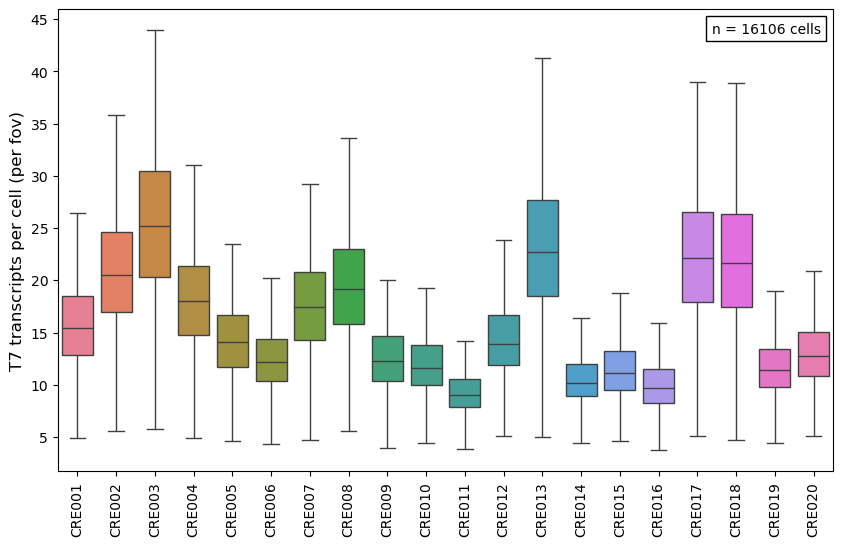

In [66]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot([all_cbg.groupby('fov')[i].mean() for i in all_cbg.columns[:-2]], showfliers=False)
plt.xticks(np.arange(20), all_cbg.columns[:20], rotation=90);
ax.set_ylabel('T7 transcripts per cell (per fov)', fontsize=12)
# ax.set_title('Counts per cell')

numcells = len(all_cbg)

anchored_text = AnchoredText(f"n = {numcells} cells", loc=1)
ax.add_artist(anchored_text)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ/figures/normalized_mean_CRE_counts_per_FOV_boxplot_231227.png', dpi=600)
plt.show()